# Стилометрия: 46 признаков + LightGBM

Baseline B показал F1=0.759 на 10 стилевых признаках. Расширяем набор до 46 topic-инвариантных признаков и заменяем LogReg на gradient boosting. Если прирост значительный - в стиле есть сигнал, который линейная модель не улавливала.

## Окружение

In [1]:
import sys
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from stylometric_features import (
    ALL_FEATURES,
    FEATURE_GROUPS,
    extract_all,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
np.random.seed(42)

DATA_DIR = Path.cwd().parent / "data" / "splits"
ARTIFACTS_DIR = Path.cwd().parent / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f"Features: {len(ALL_FEATURES)}")
for group, feats in FEATURE_GROUPS.items():
    print(f"  {group}: {len(feats)}")

Features: 45
  base: 10
  lexical: 7
  punctuation: 7
  structure: 4
  function_words: 12
  ngram_entropy: 3
  repetition: 2


c:\Users\vlad_\Project__\ai-text-trust-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка topic-matched splits

In [2]:
train = pd.read_json(DATA_DIR / "train_tm.jsonl", lines=True)
val   = pd.read_json(DATA_DIR / "val_tm.jsonl", lines=True)
test  = pd.read_json(DATA_DIR / "test_tm.jsonl", lines=True)
holdout = pd.read_json(DATA_DIR / "holdout_tm_unseen.jsonl", lines=True)

test_clean = test[test["source_model"] != "adversarial"].copy()
test_adv   = test[test["source_model"] == "adversarial"].copy()

for name, df in [("train", train), ("val", val),
                 ("test_clean", test_clean), ("test_adv", test_adv),
                 ("holdout", holdout)]:
    vc = df["label"].value_counts()
    print(f"{name:12s}: {len(df):>6,}  (human={vc.get(0,0):,}, AI={vc.get(1,0):,})")

train       :  9,000  (human=4,500, AI=4,500)
val         :  1,200  (human=600, AI=600)
test_clean  :  1,800  (human=900, AI=900)
test_adv    :    511  (human=0, AI=511)
holdout     : 12,000  (human=6,000, AI=6,000)


## Вычисление 46 признаков

Все признаки topic-инвариантные, частотные нормализованы на word_count.

In [3]:
feat_train = extract_all(train)
feat_val   = extract_all(val)
feat_test  = extract_all(test_clean)
feat_hold  = extract_all(holdout)
feat_adv   = extract_all(test_adv)

print(f"Train: {feat_train.shape}")
print(f"Val:   {feat_val.shape}")
print(f"Test:  {feat_test.shape}")
print(f"Holdout: {feat_hold.shape}")
print(f"Adversarial: {feat_adv.shape}")

Train: (9000, 45)
Val:   (1200, 45)
Test:  (1800, 45)
Holdout: (12000, 45)
Adversarial: (511, 45)


### Feature sanity check

Проверим NaN, inf, константы и корреляцию с label.

In [4]:
# NaN / inf
print(f"NaN: {feat_train.isna().sum().sum()}")
print(f"Inf: {np.isinf(feat_train.values).sum()}")
print()

# константы (std == 0)
const = feat_train.columns[feat_train.std() == 0].tolist()
if const:
    print(f"Константные фичи: {const}")
else:
    print("Константных фичей нет")
print()

# top-10 корреляция с label
corr = feat_train.corrwith(train["label"]).abs().sort_values(ascending=False)
print("Top-10 корреляция с label:")
print(corr.head(10).to_string())

NaN: 0
Inf: 0

Константных фичей нет

Top-10 корреляция с label:
char_bigram_entropy     0.645209
char_trigram_entropy    0.557175
punct_density           0.529746
cyrillic_ratio          0.504288
digit_ratio             0.477413
word_bigram_entropy     0.454343
avg_word_len            0.443509
word_count              0.424328
sentence_count          0.415067
text_len                0.410823


### Корреляционная матрица признаков

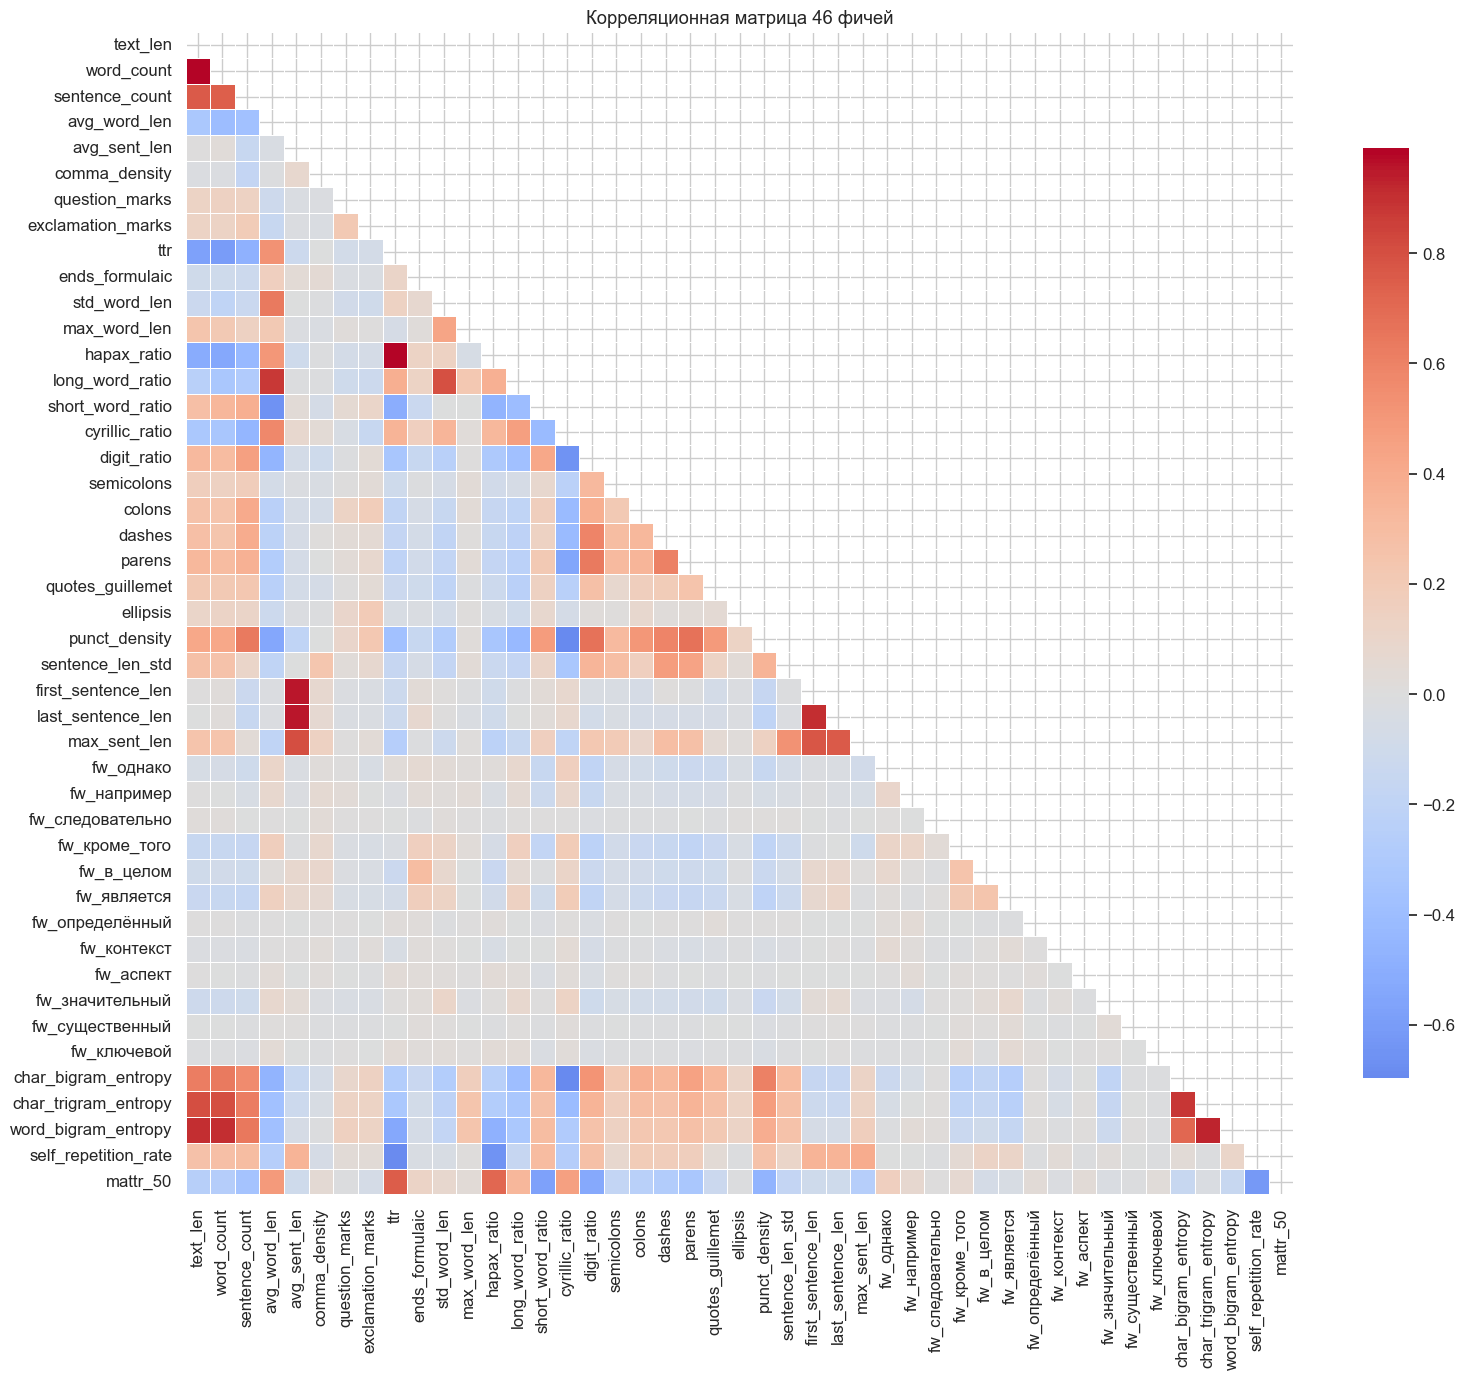

In [5]:
fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = feat_train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Корреляционная матрица 46 фичей")
plt.tight_layout()
plt.show()

## LightGBM на 46 признаках

Gradient boosting позволяет учесть нелинейные взаимодействия между признаками, которые LogReg не улавливает.

In [6]:
X_train = feat_train[ALL_FEATURES].values
X_val   = feat_val[ALL_FEATURES].values
y_train = train["label"].values
y_val   = val["label"].values

dtrain = lgb.Dataset(X_train, label=y_train, feature_name=ALL_FEATURES)
dval   = lgb.Dataset(X_val, label=y_val, feature_name=ALL_FEATURES, reference=dtrain)

params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 6,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "random_state": 42,
    "verbose": -1,
    "n_jobs": -1,
}

model = lgb.train(
    params, dtrain,
    num_boost_round=1000,
    valid_sets=[dval],
    callbacks=[
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(100),
    ],
)

print(f"\nBest iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.105735
[200]	valid_0's binary_logloss: 0.0831961
[300]	valid_0's binary_logloss: 0.076543
Early stopping, best iteration is:
[322]	valid_0's binary_logloss: 0.0760782

Best iteration: 322


Early stopping на итерации 322/1000, val logloss = 0.076. Модель сходится быстро, переобучения нет.

## Evaluation на test_tm

In [7]:
X_test = feat_test[ALL_FEATURES].values
y_test = test_clean["label"].values

prob_test = model.predict(X_test)
pred_test = (prob_test > 0.5).astype(int)

print("=== Stylometric (46 feat + LightGBM) - test_tm ===")
print(classification_report(y_test, pred_test,
      target_names=["human", "AI"], digits=3))

f1_stylo = f1_score(y_test, pred_test, average="macro")
acc_stylo = accuracy_score(y_test, pred_test)
auc_stylo = roc_auc_score(y_test, prob_test)

print(f"F1-macro: {f1_stylo:.3f}")
print(f"Accuracy: {acc_stylo:.3f}")
print(f"AUC-ROC:  {auc_stylo:.3f}")

# per-domain
print("\nPer-domain:")
for dom in sorted(test_clean["domain"].unique()):
    mask = test_clean["domain"].values == dom
    f1_d = f1_score(y_test[mask], pred_test[mask], average="macro")
    print(f"  {dom:8s}: F1={f1_d:.3f}  n={mask.sum()}")

# per-model
print("\nPer-model (AI recall):")
ai_mask = y_test == 1
for mdl in sorted(test_clean.loc[ai_mask.astype(bool), "source_model"].unique()):
    mask = (test_clean["source_model"].values == mdl) & ai_mask
    recall = pred_test[mask].mean()
    print(f"  {mdl:28s}: recall={recall:.3f}  n={mask.sum()}")

=== Stylometric (46 feat + LightGBM) - test_tm ===
              precision    recall  f1-score   support

       human      0.976     0.969     0.973       900
          AI      0.969     0.977     0.973       900

    accuracy                          0.973      1800
   macro avg      0.973     0.973     0.973      1800
weighted avg      0.973     0.973     0.973      1800

F1-macro: 0.973
Accuracy: 0.973
AUC-ROC:  0.998

Per-domain:
  essay   : F1=0.973  n=600
  news    : F1=0.970  n=600
  wiki    : F1=0.975  n=600

Per-model (AI recall):
  GigaChat                    : recall=0.978  n=314
  llama-3.3-70b-versatile     : recall=0.994  n=313
  yandexgpt-lite              : recall=0.956  n=273


F1 = 0.973, прирост +21.4 п.п. над Baseline B (0.759). По доменам стабильно: essay 0.973, news 0.970, wiki 0.975.

Recall по моделям: Llama 0.994, GigaChat 0.978, YandexGPT-Lite 0.956. Llama детектируется лучше остальных - генерирует более однотипные тексты.

## Holdout - unseen Qwen3-32B

In [8]:
X_hold = feat_hold[ALL_FEATURES].values
y_hold = holdout["label"].values

prob_hold = model.predict(X_hold)
pred_hold = (prob_hold > 0.5).astype(int)

print("=== Stylometric - holdout_tm (Qwen3 unseen) ===")
print(classification_report(y_hold, pred_hold,
      target_names=["human", "AI"], digits=3))

f1_hold = f1_score(y_hold, pred_hold, average="macro")
auc_hold = roc_auc_score(y_hold, prob_hold)
print(f"F1-macro: {f1_hold:.3f}")
print(f"AUC-ROC:  {auc_hold:.3f}")

# per-domain holdout
print("\nPer-domain (holdout):")
for dom in sorted(holdout["domain"].unique()):
    mask = holdout["domain"].values == dom
    if mask.sum() < 2:
        continue
    f1_d = f1_score(y_hold[mask], pred_hold[mask], average="macro")
    ai_m = mask & (y_hold == 1)
    recall_ai = pred_hold[ai_m].mean() if ai_m.sum() > 0 else 0
    print(f"  {dom:8s}: F1={f1_d:.3f}  AI_recall={recall_ai:.3f}  n={mask.sum()}")

=== Stylometric - holdout_tm (Qwen3 unseen) ===
              precision    recall  f1-score   support

       human      0.544     0.964     0.696      6000
          AI      0.844     0.193     0.313      6000

    accuracy                          0.578     12000
   macro avg      0.694     0.578     0.505     12000
weighted avg      0.694     0.578     0.505     12000

F1-macro: 0.505
AUC-ROC:  0.831

Per-domain (holdout):
  essay   : F1=0.316  AI_recall=0.038  n=3275
  news    : F1=0.643  AI_recall=0.356  n=5007
  wiki    : F1=0.494  AI_recall=0.183  n=3718


Провал на holdout (F1=0.505, AI recall=0.232) - модель классифицирует большинство текстов как human. Сравним распределения top-5 SHAP-признаков между train AI и Qwen3.

In [9]:
# сравнение top-5 SHAP фичей: train AI vs Qwen3
top_shap = ["last_sentence_len", "sentence_len_std", "hapax_ratio",
            "char_bigram_entropy", "punct_density"]

train_ai_feats = feat_train.loc[train["label"] == 1]
qwen_feats = feat_hold.loc[holdout["label"] == 1]

print("Распределения top-5 SHAP фичей: train AI vs Qwen3")
print(f"{'feature':20s}  {'train_AI':>10s}  {'Qwen3':>10s}  {'diff':>8s}")
for feat in top_shap:
    t_mean = train_ai_feats[feat].mean()
    q_mean = qwen_feats[feat].mean()
    diff = q_mean - t_mean
    print(f"{feat:20s}  {t_mean:10.3f}  {q_mean:10.3f}  {diff:+8.3f}")

Распределения top-5 SHAP фичей: train AI vs Qwen3
feature                 train_AI       Qwen3      diff
last_sentence_len         27.182      21.813    -5.369
sentence_len_std           5.179       6.243    +1.064
hapax_ratio                0.609       0.557    -0.051
char_bigram_entropy        7.755       8.034    +0.279
punct_density              0.018       0.026    +0.008


## Adversarial

In [10]:
if len(test_adv) > 0:
    X_adv = feat_adv[ALL_FEATURES].values
    prob_adv = model.predict(X_adv)
    pred_adv = (prob_adv > 0.5).astype(int)
    recall_adv = pred_adv.mean()
    print(f"Adversarial (n={len(test_adv)}): "
          f"recall={recall_adv:.3f}  avg_prob={prob_adv.mean():.3f}")

Adversarial (n=511): recall=0.795  avg_prob=0.799


In [11]:
# bootstrap CI
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except ValueError:
            continue
    lo = np.percentile(scores, 2.5)
    hi = np.percentile(scores, 97.5)
    return np.median(scores), lo, hi

for name, y, pred, prob in [
    ("test_tm", y_test, pred_test, prob_test),
    ("holdout", y_hold, pred_hold, prob_hold),
]:
    f1_med, f1_lo, f1_hi = bootstrap_ci(
        y, pred, lambda yt, yp: f1_score(yt, yp, average="macro"))
    auc_med, auc_lo, auc_hi = bootstrap_ci(
        y, prob, lambda yt, yp: roc_auc_score(yt, yp))
    print(f"{name:10s}: F1={f1_med:.3f} [{f1_lo:.3f}, {f1_hi:.3f}]  "
          f"AUC={auc_med:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]")


test_tm   : F1=0.973 [0.965, 0.980]  AUC=0.998 [0.996, 0.999]
holdout   : F1=0.505 [0.496, 0.514]  AUC=0.831 [0.824, 0.839]


## SHAP feature importance

Какие признаки вносят наибольший вклад в предсказания?

c:\Users\vlad_\Project__\ai-text-trust-service\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


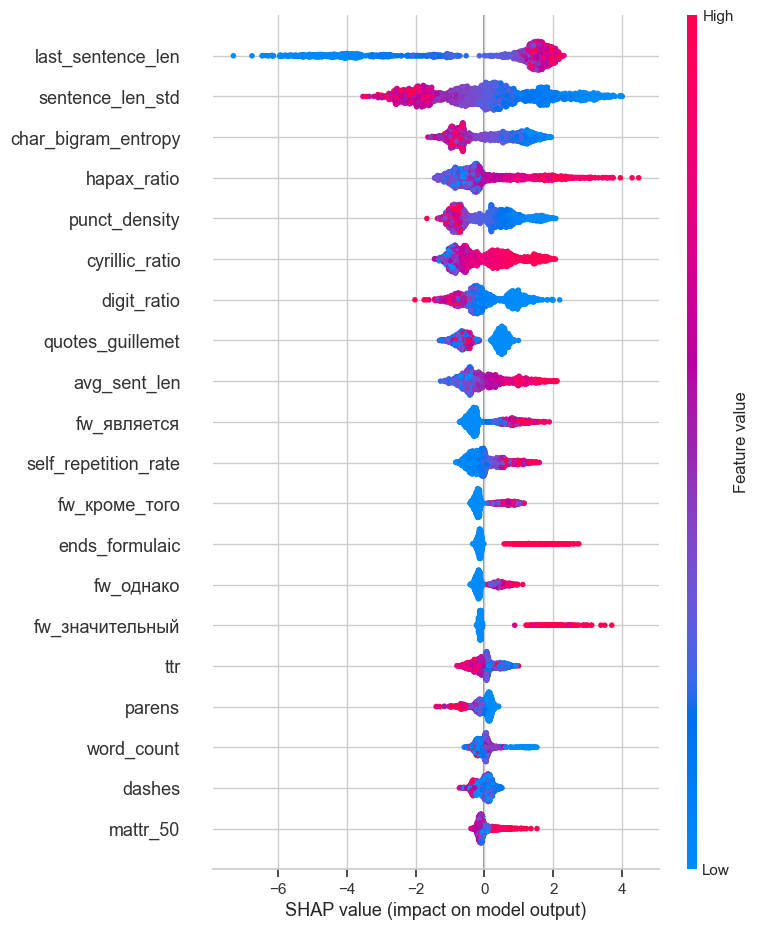

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# если binary - shap_values может быть list из 2
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # класс AI

# beeswarm plot
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_test,
                  feature_names=ALL_FEATURES,
                  max_display=20, show=False)
plt.tight_layout()
plt.show()

Top-20 фичей по |SHAP|:
last_sentence_len       2.094758
sentence_len_std        1.306823
char_bigram_entropy     0.843519
hapax_ratio             0.792248
punct_density           0.702647
cyrillic_ratio          0.702016
digit_ratio             0.586792
quotes_guillemet        0.569970
avg_sent_len            0.542921
fw_является             0.515651
self_repetition_rate    0.360187
fw_кроме_того           0.336463
ends_formulaic          0.289832
fw_однако               0.280946
fw_значительный         0.257502
ttr                     0.243712
parens                  0.199202
word_count              0.176334
dashes                  0.172847
mattr_50                0.163391


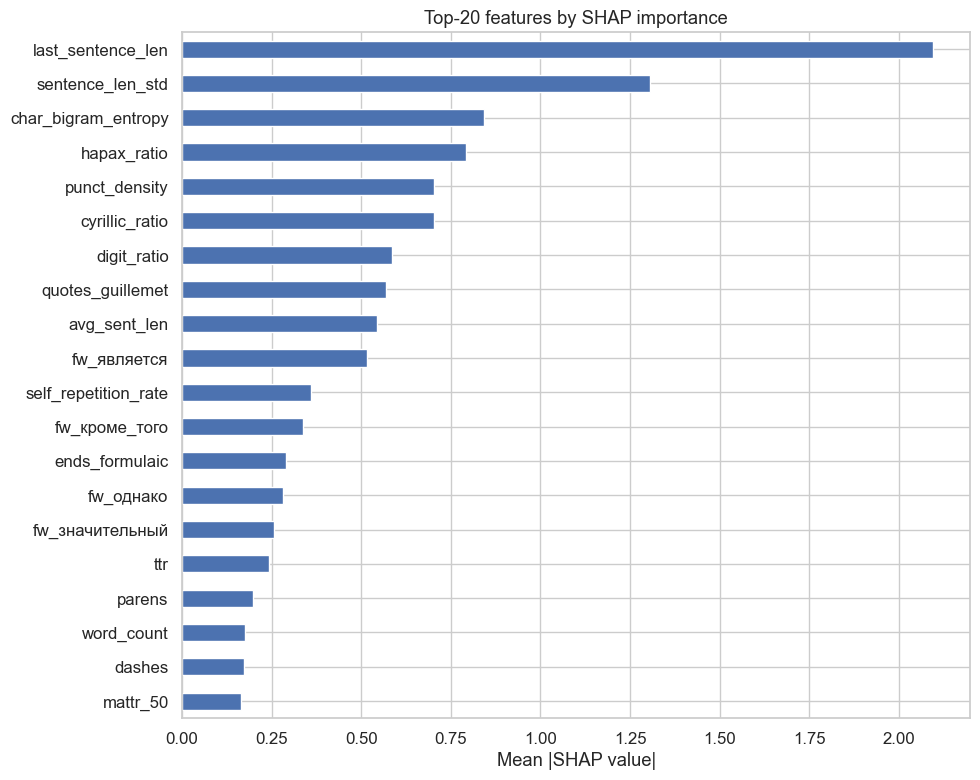

In [13]:
# bar plot - средний абсолютный SHAP
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.Series(mean_shap, index=ALL_FEATURES).sort_values(ascending=False)

print("Top-20 фичей по |SHAP|:")
print(shap_df.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
shap_df.head(20).plot.barh(ax=ax)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top-20 features by SHAP importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Top-3 по SHAP: `last_sentence_len` (2.09), `sentence_len_std` (1.31), `char_bigram_entropy` (0.84). Структурные признаки доминируют: LLM генерируют предложения более однородной длины и с менее разнообразными n-граммами.

`fw_является` (0.52) и `fw_кроме_того` (0.34) попали в top-20, но их вклад в 4-6 раз ниже структурных признаков.

## Ablation study

Убираем группы признаков по одной и измеряем падение F1. Отдельный эксперимент: LightGBM на 10 базовых признаках (как Baseline B, но нелинейная модель) - изолирует вклад модели от вклада признаков.

In [14]:
# ablation: убираем одну группу
ablation_results = []

# full model
ablation_results.append({
    "variant": "ALL (46 feat)",
    "n_features": len(ALL_FEATURES),
    "F1": f1_stylo,
})

for group_name, group_feats in FEATURE_GROUPS.items():
    # убираем эту группу
    remaining = [f for f in ALL_FEATURES if f not in group_feats]
    if not remaining:
        continue

    dt = lgb.Dataset(
        feat_train[remaining].values, label=y_train,
        feature_name=remaining,
    )
    dv = lgb.Dataset(
        feat_val[remaining].values, label=y_val,
        feature_name=remaining, reference=dt,
    )
    m = lgb.train(
        params, dt, num_boost_round=1000, valid_sets=[dv],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    pred = (m.predict(feat_test[remaining].values) > 0.5).astype(int)
    f1 = f1_score(y_test, pred, average="macro")
    ablation_results.append({
        "variant": f"without {group_name} ({len(group_feats)})",
        "n_features": len(remaining),
        "F1": f1,
    })

# LightGBM на 10 базовых (вклад модели vs фичей)
base_feats = FEATURE_GROUPS["base"]
dt_base = lgb.Dataset(
    feat_train[base_feats].values, label=y_train,
    feature_name=base_feats,
)
dv_base = lgb.Dataset(
    feat_val[base_feats].values, label=y_val,
    feature_name=base_feats, reference=dt_base,
)
m_base = lgb.train(
    params, dt_base, num_boost_round=1000, valid_sets=[dv_base],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
pred_base = (m_base.predict(feat_test[base_feats].values) > 0.5).astype(int)
f1_base_lgb = f1_score(y_test, pred_base, average="macro")
ablation_results.append({
    "variant": "base 10 only (LightGBM)",
    "n_features": len(base_feats),
    "F1": f1_base_lgb,
})

abl_df = pd.DataFrame(ablation_results)
abl_df["delta"] = abl_df["F1"] - f1_stylo
print(abl_df.to_string(index=False, float_format="%.3f"))

                    variant  n_features    F1  delta
              ALL (46 feat)          45 0.973  0.000
          without base (10)          35 0.968 -0.005
        without lexical (7)          38 0.968 -0.004
    without punctuation (7)          38 0.967 -0.006
      without structure (4)          41 0.959 -0.014
without function_words (12)          33 0.976  0.003
  without ngram_entropy (3)          42 0.970 -0.003
     without repetition (2)          43 0.972 -0.001
    base 10 only (LightGBM)          10 0.869 -0.104


## Сравнение: B vs Stylometric vs C

Все модели на test_tm.

In [15]:
# Baseline B (LogReg, 10 feat) на test_tm - пересчитываем
scaler = StandardScaler()
base_feats = FEATURE_GROUPS["base"]
X_train_B = scaler.fit_transform(feat_train[base_feats].values)
X_val_B = scaler.transform(feat_val[base_feats].values)

# tune C
best_c, best_f1_b = 1.0, 0.0
for c in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]:
    lr = LogisticRegression(C=c, solver="lbfgs", max_iter=5000, random_state=42)
    lr.fit(X_train_B, y_train)
    pred = lr.predict(scaler.transform(feat_val[base_feats].values))
    f1 = f1_score(y_val, pred, average="macro")
    if f1 > best_f1_b:
        best_f1_b = f1
        best_c = c

# retrain on train+val
X_tv_B = scaler.fit_transform(
    pd.concat([feat_train, feat_val])[base_feats].values
)
y_tv = pd.concat([train, val])["label"].values
model_B = LogisticRegression(C=best_c, solver="lbfgs", max_iter=5000, random_state=42)
model_B.fit(X_tv_B, y_tv)

X_test_B = scaler.transform(feat_test[base_feats].values)
pred_B = model_B.predict(X_test_B)
prob_B = model_B.predict_proba(X_test_B)[:, 1]
f1_B = f1_score(y_test, pred_B, average="macro")
auc_B = roc_auc_score(y_test, prob_B)

print("=== Сравнение на test_tm ===")
print(f"Baseline B (10 feat, LogReg):     F1={f1_B:.3f}  AUC={auc_B:.3f}")
print(f"LightGBM (10 feat):               F1={f1_base_lgb:.3f}")
print(f"Stylometric (46 feat, LightGBM):  F1={f1_stylo:.3f}  AUC={auc_stylo:.3f}")
print()
print(f"Вклад нелинейности (LightGBM 10 - LogReg 10): +{f1_base_lgb - f1_B:.3f}")
print(f"Вклад новых фичей (LightGBM 46 - LightGBM 10): +{f1_stylo - f1_base_lgb:.3f}")
print(f"Общий прирост (Stylo - Baseline B): +{f1_stylo - f1_B:.3f}")

=== Сравнение на test_tm ===
Baseline B (10 feat, LogReg):     F1=0.803  AUC=0.896
LightGBM (10 feat):               F1=0.869
Stylometric (46 feat, LightGBM):  F1=0.973  AUC=0.998

Вклад нелинейности (LightGBM 10 - LogReg 10): +0.066
Вклад новых фичей (LightGBM 46 - LightGBM 10): +0.104
Общий прирост (Stylo - Baseline B): +0.169


## Сводная таблица

In [16]:
summary_rows = [
    {"model": "B (10 feat, LogReg)", "test_tm": f1_B,
     "holdout": f1_score(y_hold, model_B.predict(scaler.transform(feat_hold[base_feats].values)), average="macro"),
     "adversarial_recall": model_B.predict(scaler.transform(feat_adv[base_feats].values)).mean() if len(test_adv) > 0 else None},
    {"model": "Stylometric (46 feat, LightGBM)", "test_tm": f1_stylo,
     "holdout": f1_hold,
     "adversarial_recall": recall_adv if len(test_adv) > 0 else None},
]

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False, float_format="%.3f"))

                          model  test_tm  holdout  adversarial_recall
            B (10 feat, LogReg)    0.803    0.349               0.532
Stylometric (46 feat, LightGBM)    0.973    0.505               0.795


## Сохранение модели

In [17]:
import joblib

model.save_model(str(ARTIFACTS_DIR / "stylometric_lgb.txt"))
joblib.dump(scaler, ARTIFACTS_DIR / "stylometric_scaler.joblib")

print(f"LightGBM: {ARTIFACTS_DIR / 'stylometric_lgb.txt'}")
print(f"Scaler: {ARTIFACTS_DIR / 'stylometric_scaler.joblib'}")

LightGBM: c:\Users\vlad_\Project__\ai-text-trust-service\artifacts\stylometric_lgb.txt
Scaler: c:\Users\vlad_\Project__\ai-text-trust-service\artifacts\stylometric_scaler.joblib


## Выводы

Стилометрия с 46 признаками и LightGBM: F1=0.973 на test_tm, прирост +21.4 п.п. над Baseline B (10 признаков, LogReg).

Декомпозиция прироста: расширение набора признаков дало +10.4 п.п., нелинейность модели +6.6 п.п. Feature engineering оказался важнее выбора модели.

SHAP top-5: `last_sentence_len`, `sentence_len_std`, `hapax_ratio`, `char_bigram_entropy`, `punct_density`. Структурные и энтропийные признаки доминируют над лексическими маркерами.

Проблема обобщения: F1=0.505 на holdout (unseen Qwen3). Стилометрические признаки не переносятся на новый генератор - Qwen3 имеет другое распределение длин предложений и энтропии. Для робастной детекции нужна модель, обучающаяся на контексте, а не на агрегированных статистиках.